In [1]:
%matplotlib inline
import os, re, json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50
from torchvision import transforms

if torch.cuda.is_available():      device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                              device = torch.device('cpu')
print(f'Device: {device}')

BASE       = os.getcwd()
DATA_ROOT  = os.path.join(BASE, 'retrieval_strategists_full_dataset_in_partitions_v1')
CKPT_PATH  = os.path.join(BASE, 'best_model.pth')
LOG_PATH   = os.path.join(BASE, 'training_log.txt')   

VAL_QUERY   = os.path.join(DATA_ROOT, 'validation', 'query')
VAL_GALLERY = os.path.join(DATA_ROOT, 'validation', 'gallery')
TEST_QUERY   = os.path.join(DATA_ROOT, 'test', 'query')
TEST_GALLERY = os.path.join(DATA_ROOT, 'test', 'gallery')

Device: mps


## 1. Training Curve

In [2]:
epochs, losses, top1s, top5s, top10s, scores = [], [], [], [], [], []

if os.path.exists(LOG_PATH):
    with open(LOG_PATH) as f:
        for line in f:
            # Match epoch loss line
            m = re.search(r'Epoch \[(\d+)/.+\] loss=([\d.]+)', line)
            if m:
                epochs.append(int(m.group(1)))
                losses.append(float(m.group(2)))
            # Match validation score line
            m = re.search(r'Top-1: ([\d.]+) \| Top-5: ([\d.]+) \| Top-10: ([\d.]+) \| Score: ([\d.]+)', line)
            if m:
                top1s.append(float(m.group(1)))
                top5s.append(float(m.group(2)))
                top10s.append(float(m.group(3)))
                scores.append(float(m.group(4)))
else:
    print(f'Log file not found at {LOG_PATH}')
    print('Run:  python train_arcface.py | tee training_log.txt')

if epochs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, losses, 'o-', color='steelblue', linewidth=2)
    axes[0].set_title('ArcFace Training Loss', fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    e = list(range(1, len(scores)+1))
    axes[1].plot(e, top1s,  's-', label='Top-1',  color='crimson',    linewidth=2)
    axes[1].plot(e, top5s,  'o-', label='Top-5',  color='darkorange',  linewidth=2)
    axes[1].plot(e, top10s, '^-', label='Top-10', color='forestgreen', linewidth=2)
    axes[1].set_title('Validation Retrieval Accuracy', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE, 'training_curves.png'), dpi=150)
    plt.show()
    print(f'Best score: {max(scores):.1f}/1000 at epoch {scores.index(max(scores))+1}')

## 2. Load the Best Model

In [3]:
class EmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        backbone = resnet50(weights=None)
        self.backbone  = nn.Sequential(*list(backbone.children())[:-1])
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, embedding_dim, bias=False),
            nn.BatchNorm1d(embedding_dim),
        )
    def forward(self, x):
        return self.embedding(self.backbone(x))

_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

ckpt = torch.load(CKPT_PATH, map_location=device)
emb_dim = ckpt.get('embedding_dim', 512)
model = EmbeddingModel(embedding_dim=emb_dim).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded checkpoint — epoch {ckpt.get("epoch","?")}  '
      f'val_score={ckpt.get("val_score","?"):.1f}/1000')

Loaded checkpoint — epoch 17  val_score=407.0/1000


## 3. Extract Validation Features

In [7]:
@torch.no_grad()
def extract_features(folder, batch_size=128):
    filenames = sorted(f for f in os.listdir(folder)
                       if f.lower().endswith(('.jpg','.jpeg','.png')))
    images = [Image.open(os.path.join(folder, f)).convert('RGB') for f in filenames]
    feats = []
    for i in range(0, len(images), batch_size):
        batch = torch.stack([eval_tf(img) for img in images[i:i+batch_size]]).to(device)
        f = F.normalize(model(batch), p=2, dim=1)
        feats.append(f.cpu())
    return torch.cat(feats, 0), filenames, images

print('Extracting validation query features...')
q_feats, q_files, q_imgs = extract_features(VAL_QUERY)
print('Extracting validation gallery features...')
g_feats, g_files, g_imgs = extract_features(VAL_GALLERY)

sim = torch.matmul(q_feats, g_feats.T)
_, top10_idx = torch.topk(sim, k=10, dim=1)

q_ids = [f.rsplit('_',1)[0] for f in q_files]
g_ids = [f.rsplit('_',1)[0] for f in g_files]

# Compute per-query correctness
correct_top1  = [g_ids[top10_idx[i,0].item()] == q_ids[i] for i in range(len(q_files))]
correct_top5  = [q_ids[i] in [g_ids[top10_idx[i,k].item()] for k in range(5)]  for i in range(len(q_files))]
correct_top10 = [q_ids[i] in [g_ids[top10_idx[i,k].item()] for k in range(10)] for i in range(len(q_files))]

n = len(q_files)
score = sum(correct_top1)/n*600 + sum(correct_top5)/n*300 + sum(correct_top10)/n*100
print(f'\nValidation  Top-1: {sum(correct_top1)/n:.3f} | '
      f'Top-5: {sum(correct_top5)/n:.3f} | '
      f'Top-10: {sum(correct_top10)/n:.3f} | '
      f'Score: {score:.1f}/1000')

Extracting validation query features...
Extracting validation gallery features...

Validation  Top-1: 0.310 | Top-5: 0.530 | Top-10: 0.620 | Score: 407.0/1000


## 4. Visualise Retrieval Results
Shows the query image on the left, then the top-10 retrieved gallery images.  
**Green border** = correct identity, **red border** = wrong.

In [8]:
def show_retrieval(query_indices, title=''):
    """Display retrieval results for a list of query indices."""
    n_queries = len(query_indices)
    cols = 11   # 1 query + 10 retrieved
    fig, axes = plt.subplots(n_queries, cols, figsize=(cols * 1.6, n_queries * 1.8))
    if n_queries == 1:
        axes = [axes]

    for row, qi in enumerate(query_indices):
        # Query image
        ax = axes[row][0]
        ax.imshow(q_imgs[qi])
        ax.set_title(f'Query\n{q_ids[qi]}', fontsize=7, color='navy')
        for spine in ax.spines.values():
            spine.set_edgecolor('navy'); spine.set_linewidth(3)
        ax.set_xticks([]); ax.set_yticks([])

        # Retrieved gallery images
        for k in range(10):
            gi  = top10_idx[qi, k].item()
            ax  = axes[row][k + 1]
            ax.imshow(g_imgs[gi])
            correct = (g_ids[gi] == q_ids[qi])
            colour  = 'limegreen' if correct else 'red'
            label   = '✓' if correct else '✗'
            ax.set_title(f'#{k+1} {label}', fontsize=7, color=colour)
            for spine in ax.spines.values():
                spine.set_edgecolor(colour); spine.set_linewidth(3)
            ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

q_imgs available: 100
successes: NOT DEFINED
backend: inline


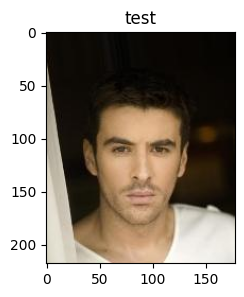

In [9]:
# Quick diagnostic — run this in a new cell
print("q_imgs available:", len(q_imgs) if 'q_imgs' in dir() else "NOT DEFINED")
print("successes:", successes if 'successes' in dir() else "NOT DEFINED")

# Try a bare minimum plot
import matplotlib
print("backend:", matplotlib.get_backend())
fig, ax = plt.subplots(1,1, figsize=(3,3))
ax.imshow(q_imgs[0])
ax.set_title("test")
plt.show()

Showing 5 Top-1 successes


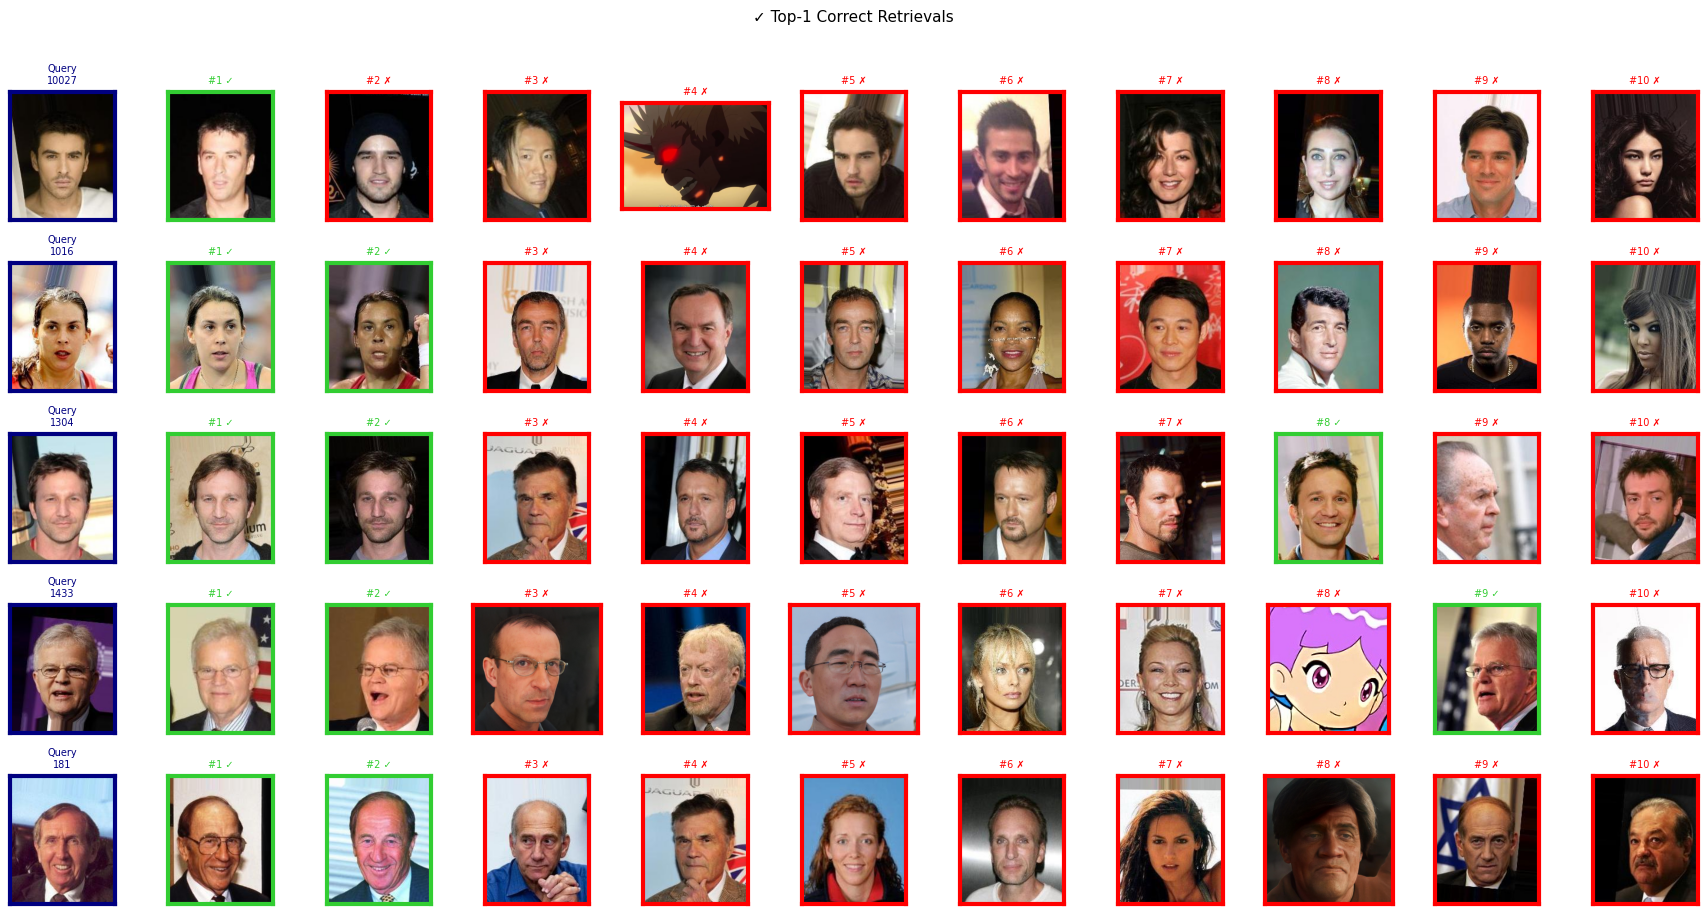

In [ ]:
# Successes: queries where Top-1 is correct
successes = [i for i, c in enumerate(correct_top1) if c][:5]
print(f'Showing {len(successes)} Top-1 successes')
show_retrieval(successes, title='✓ Top-1 Correct Retrievals')

Showing 5 partial failures (wrong Top-1, correct in Top-10)


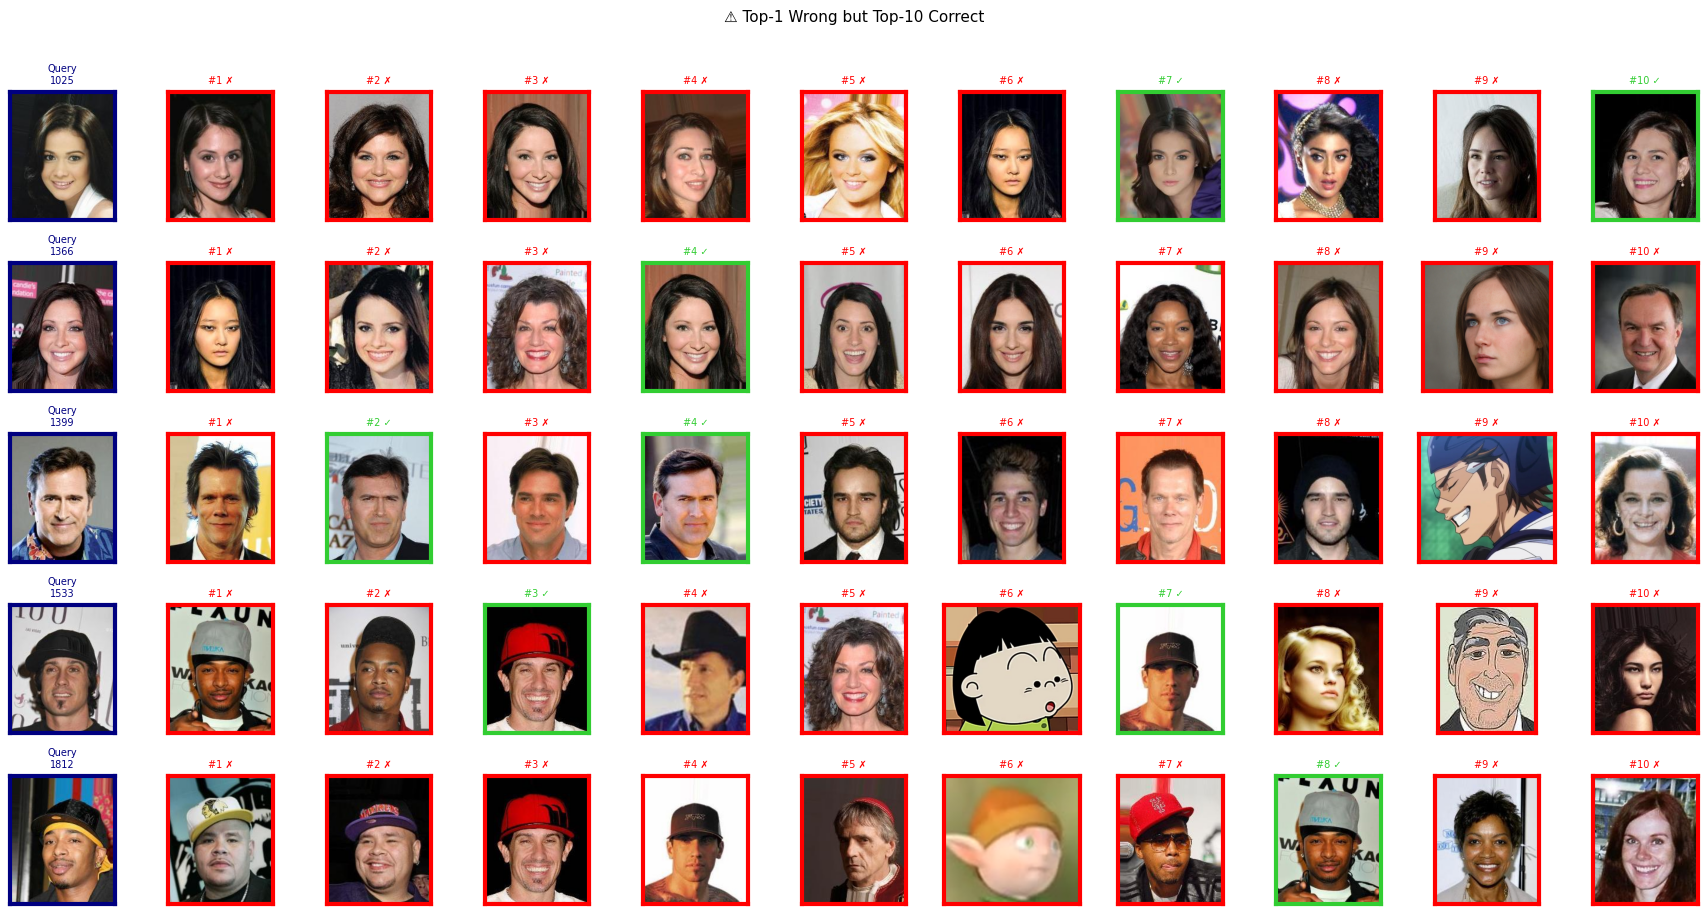

In [7]:
# ── Failures: Top-1 wrong but correct answer is in Top-10 ──
partial = [i for i, (c1, c10) in enumerate(zip(correct_top1, correct_top10)) if not c1 and c10][:5]
print(f'Showing {len(partial)} partial failures (wrong Top-1, correct in Top-10)')
show_retrieval(partial, title='⚠ Top-1 Wrong but Top-10 Correct')

Showing 5 hard failures (not in Top-10)


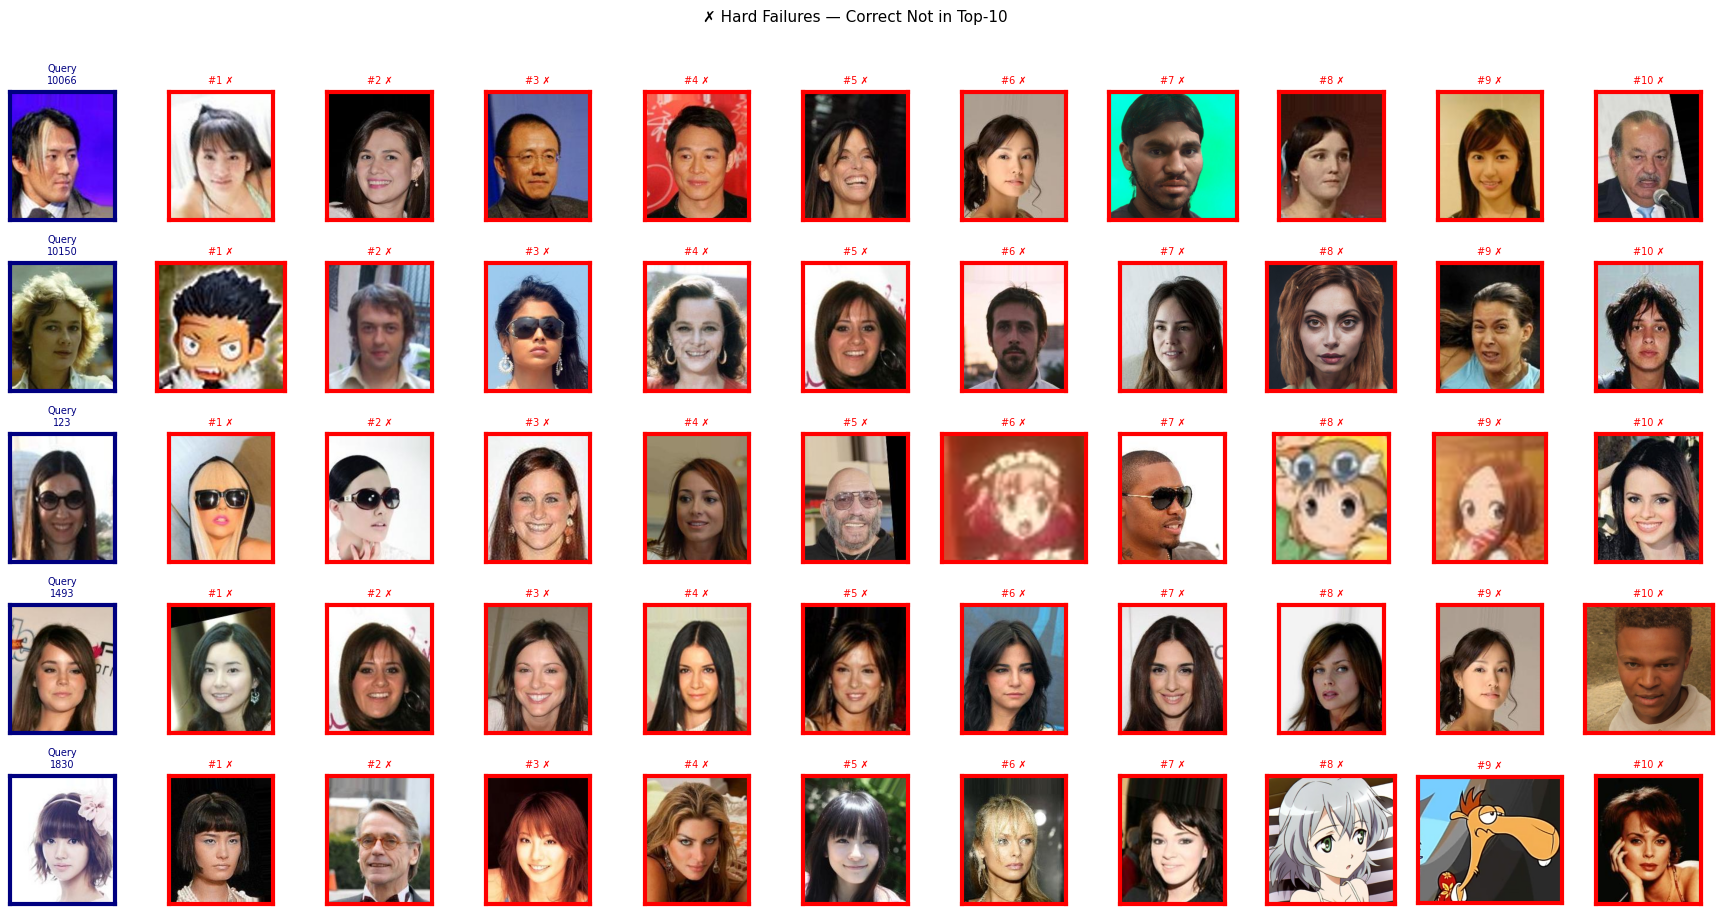

In [ ]:
# Hard failures: correct answer not even in Top-10 
hard_fail = [i for i, c in enumerate(correct_top10) if not c][:5]
print(f'Showing {len(hard_fail)} hard failures (not in Top-10)')
show_retrieval(hard_fail, title='✗ Hard Failures — Correct Not in Top-10')

---
## 5 · Score Breakdown

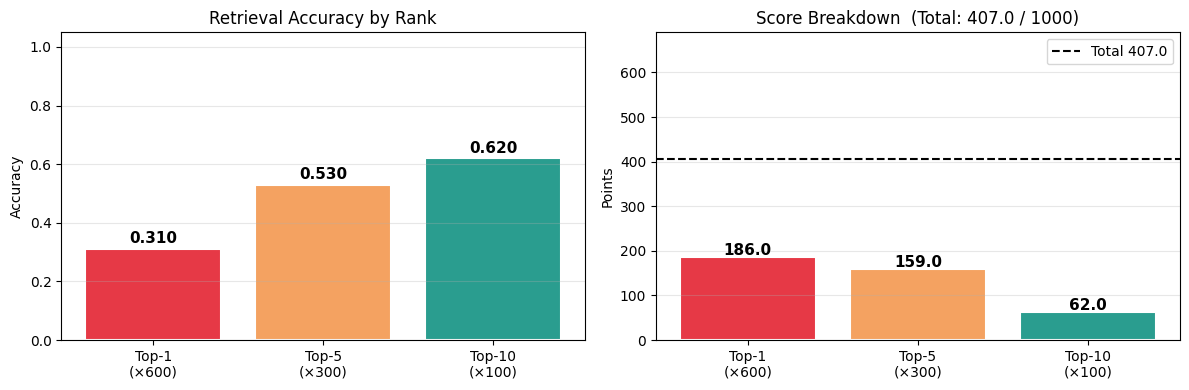

In [9]:
t1  = sum(correct_top1)  / n
t5  = sum(correct_top5)  / n
t10 = sum(correct_top10) / n

categories = ['Top-1\n(×600)', 'Top-5\n(×300)', 'Top-10\n(×100)']
accs   = [t1, t5, t10]
points = [t1*600, t5*300, t10*100]
colours = ['#e63946', '#f4a261', '#2a9d8f']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(categories, accs, color=colours, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Retrieval Accuracy by Rank', fontsize=12)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(categories, points, color=colours, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, max(600, max(points)) * 1.15)
axes[1].set_ylabel('Points')
axes[1].set_title(f'Score Breakdown  (Total: {sum(points):.1f} / 1000)', fontsize=12)
for bar, pts in zip(bars2, points):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{pts:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(sum(points), color='black', linestyle='--', linewidth=1.5, label=f'Total {sum(points):.1f}')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'score_breakdown.png'), dpi=150)
plt.show()

Top-1: 0.310 | Top-5: 0.530 | Top-10: 0.620 | Score: 407.0/1000


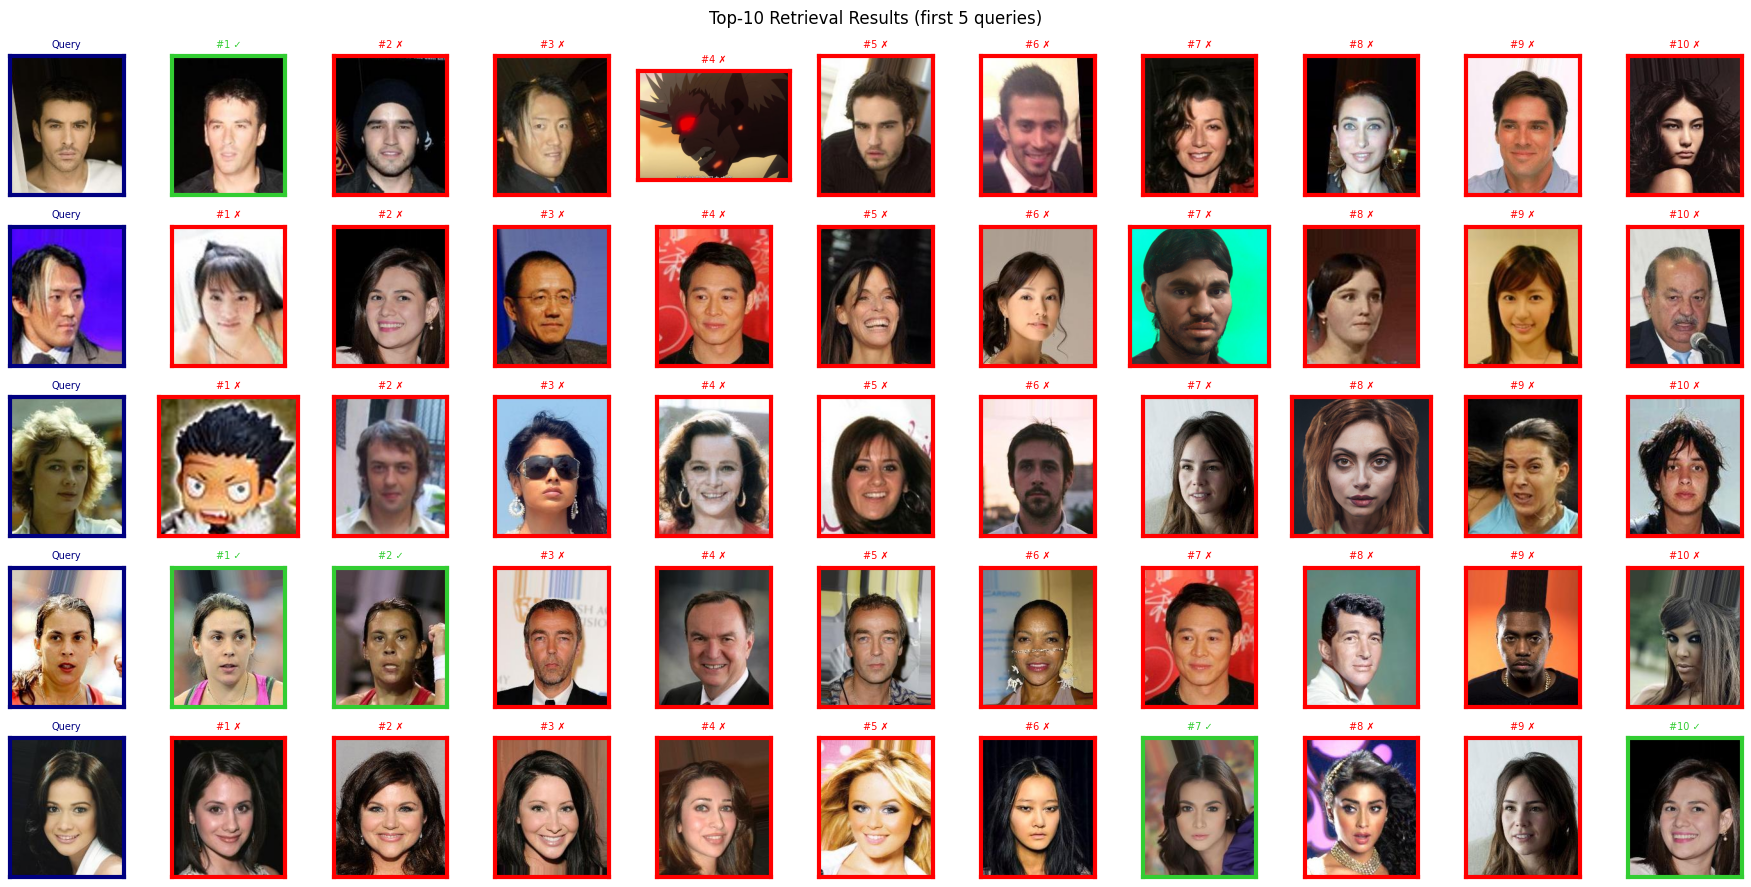

Saved to retrieval_results.png


In [10]:
%matplotlib inline
import os, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torchvision.models import resnet50
from torchvision import transforms
import matplotlib.pyplot as plt

# ── Setup ──
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
BASE = os.getcwd()
DATA = os.path.join(BASE, 'retrieval_strategists_full_dataset_in_partitions_v1')

class M(nn.Module):
    def __init__(self):
        super().__init__()
        b = resnet50(weights=None)
        self.backbone  = nn.Sequential(*list(b.children())[:-1])
        self.embedding = nn.Sequential(nn.Flatten(), nn.Linear(2048,512,bias=False), nn.BatchNorm1d(512))
    def forward(self,x): return self.embedding(self.backbone(x))

ckpt  = torch.load(os.path.join(BASE,'best_model.pth'), map_location=device)
model = M().to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

tf = transforms.Compose([transforms.Resize(256),transforms.CenterCrop(224),
                          transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def get_feats_and_imgs(folder):
    files = sorted(f for f in os.listdir(folder) if f.endswith('.jpg'))
    imgs  = [Image.open(os.path.join(folder,f)).convert('RGB') for f in files]
    with torch.no_grad():
        fs = torch.cat([F.normalize(model(torch.stack([tf(imgs[j]) for j in range(i,min(i+64,len(imgs)))]).to(device)),p=2,dim=1).cpu()
                        for i in range(0,len(imgs),64)])
    return fs, files, imgs

q_feats, q_files, q_imgs = get_feats_and_imgs(os.path.join(DATA,'validation','query'))
g_feats, g_files, g_imgs = get_feats_and_imgs(os.path.join(DATA,'validation','gallery'))

sim = torch.matmul(q_feats, g_feats.T)
_, top10 = torch.topk(sim, 10, dim=1)
q_ids = [f.rsplit('_',1)[0] for f in q_files]
g_ids = [f.rsplit('_',1)[0] for f in g_files]

# Score
n = len(q_files)
t1  = sum(g_ids[top10[i,0]] == q_ids[i] for i in range(n))
t5  = sum(q_ids[i] in [g_ids[top10[i,k]] for k in range(5)]  for i in range(n))
t10 = sum(q_ids[i] in [g_ids[top10[i,k]] for k in range(10)] for i in range(n))
print(f'Top-1: {t1/n:.3f} | Top-5: {t5/n:.3f} | Top-10: {t10/n:.3f} | Score: {t1/n*600+t5/n*300+t10/n*100:.1f}/1000')

# ── Show 5 queries ──
fig, axes = plt.subplots(5, 11, figsize=(18, 9))
for row in range(5):
    qi = row  # show first 5 queries
    axes[row,0].imshow(q_imgs[qi]); axes[row,0].set_title(f'Query', fontsize=7, color='navy')
    for spine in axes[row,0].spines.values(): spine.set_edgecolor('navy'); spine.set_linewidth(3)
    axes[row,0].set_xticks([]); axes[row,0].set_yticks([])
    for k in range(10):
        gi = top10[qi,k].item()
        ok = g_ids[gi] == q_ids[qi]
        axes[row,k+1].imshow(g_imgs[gi])
        axes[row,k+1].set_title(f'#{k+1} {"✓" if ok else "✗"}', fontsize=7, color='limegreen' if ok else 'red')
        for spine in axes[row,k+1].spines.values(): spine.set_edgecolor('limegreen' if ok else 'red'); spine.set_linewidth(3)
        axes[row,k+1].set_xticks([]); axes[row,k+1].set_yticks([])
plt.suptitle('Top-10 Retrieval Results (first 5 queries)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE,'retrieval_results.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved to retrieval_results.png')